# Lifeline AI: EDA, Retraining, and Comparison

This notebook retrains a regression model using the dataset located in the same folder as this notebook. It performs EDA, training, metrics, and predictions in step-by-step cells, then compares accuracy (within +/- 5 years) and R2 with the existing metrics in app/ml/artifacts/model_performance.csv.

In [22]:
import importlib
import subprocess
import sys

def _ensure(pkg, import_name=None):
    name = import_name or pkg
    try:
        importlib.import_module(name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

# Run once if needed
for pkg, name in [
    ("pandas", None),
    ("numpy", None),
    ("scikit-learn", "sklearn"),
    ("matplotlib", None),
    ("seaborn", None),
]:
    _ensure(pkg, name)

In [23]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

np.random.seed(42)
sns.set_theme(style="whitegrid")

In [24]:
DATA_PATH = Path("longevity_dataset_100k.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("app/data/longevity_dataset.csv")
DATA_PATH = DATA_PATH.resolve()
DATA_PATH

WindowsPath('D:/xode-2/sheryians/Machine learning/lifeline_ai/longevity_dataset_100k.csv')

In [25]:
df = pd.read_csv(DATA_PATH)
df.head()

,age,sex,education,ses,smoking,alcohol,exercise,sleep,stress,social,...,bmi,hr,bp,conditions,family,mental,env,aqi,predicted_lifespan,remaining_years
0,59,male,hs,upper_middle,former,heavy,7,9.0,5,8,...,24.7,57,139,hypertension,80_90,excellent,urban,50.1,78.5,19.5
1,29,female,graduate,lower_middle,never,never,7,8.7,7,4,...,21.4,50,129,hypertension,80_90,moderate,rural,24.3,92.5,63.5
2,45,female,hs,middle,never,light,2,9.0,6,6,...,30.9,50,153,hypertension,80_90,moderate,urban,137.6,80.1,35.1
3,32,female,hs,lower_middle,never,heavy,3,7.6,7,5,...,30.8,67,121,none,above_90,good,suburban,69.8,83.7,51.7
4,53,female,some_college,upper_middle,never,never,3,10.5,5,1,...,35.3,64,145,hypertension,below_70,good,suburban,17.5,83.8,30.8


In [26]:
df.shape

(100000, 22)

In [27]:
df.isna().sum().sort_values(ascending=False).head(10)

age          0
sex          0
education    0
ses          0
smoking      0
alcohol      0
exercise     0
sleep        0
stress       0
social       0
dtype: int64

In [28]:
TARGET = "predicted_lifespan"
LEAKY_COLS = ["remaining_years"]
feature_cols = [c for c in df.columns if c not in [TARGET] + LEAKY_COLS]

numeric_cols = df[feature_cols].select_dtypes(include=["number"]).columns.tolist()
categorical_cols = [c for c in feature_cols if c not in numeric_cols]

numeric_cols, categorical_cols

(['age',
  'exercise',
  'sleep',
  'stress',
  'social',
  'fv',
  'bmi',
  'hr',
  'bp',
  'aqi'],
 ['sex',
  'education',
  'ses',
  'smoking',
  'alcohol',
  'processed',
  'conditions',
  'family',
  'mental',
  'env'])

In [8]:
df[TARGET].describe()

count    100000.000000
mean         78.127265
std           9.580356
min          32.500000
25%          71.700000
50%          78.400000
75%          84.800000
max         115.000000
Name: predicted_lifespan, dtype: float64

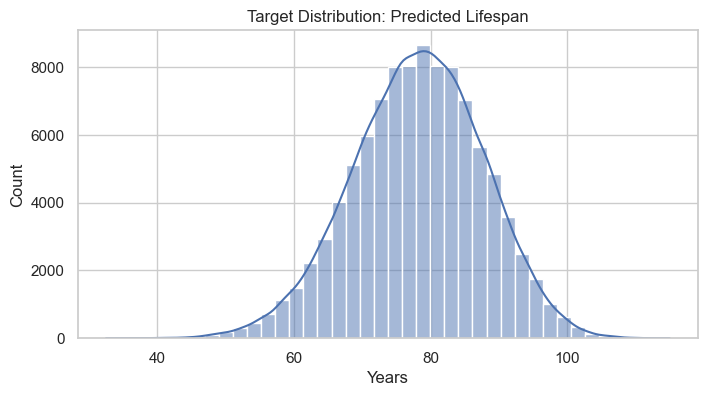

In [9]:
plt.figure(figsize=(8, 4))
sns.histplot(df[TARGET], bins=40, kde=True)
plt.title("Target Distribution: Predicted Lifespan")
plt.xlabel("Years")
plt.ylabel("Count")
plt.show()

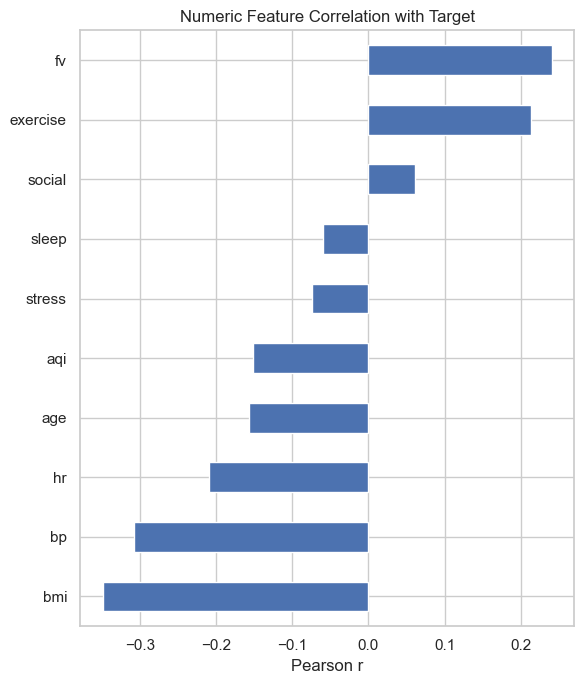

In [10]:
eda_df = df.sample(min(len(df), 5000), random_state=42)
corr = eda_df[numeric_cols + [TARGET]].corr(numeric_only=True)[TARGET].drop(TARGET).sort_values()

plt.figure(figsize=(6, 7))
corr.plot(kind="barh")
plt.title("Numeric Feature Correlation with Target")
plt.xlabel("Pearson r")
plt.tight_layout()
plt.show()

In [11]:
X = df[feature_cols]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape

((80000, 20), (20000, 20))

In [29]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
    ]
)

model = HistGradientBoostingRegressor(
    max_depth=6,
    learning_rate=0.1,
    max_iter=200,
    random_state=42,
)

pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", model),
    ]
)

pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [30]:
pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

ACC_TOL_YEARS = 5.0
accuracy = float(np.mean(np.abs(y_test - y_pred) <= ACC_TOL_YEARS))

{
    "r2": r2,
    "mae": mae,
    "rmse": rmse,
    "accuracy_within_5_years": accuracy,
}

{'r2': 0.7650025213201972,
 'mae': 3.6938735385709935,
 'rmse': np.float64(4.628283377735008),
 'accuracy_within_5_years': 0.72165}

In [31]:
cv_r2 = cross_val_score(pipe, X, y, cv=5, scoring="r2", n_jobs=-1)
cv_r2.mean(), cv_r2.std()

(np.float64(0.7670857784830741), np.float64(0.0018446143070342275))

In [17]:
existing_path = Path("app/ml/artifacts/model_performance.csv")
if existing_path.exists():
    existing = pd.read_csv(existing_path)
    existing
else:
    existing = None
    print("No existing metrics found at", existing_path)

In [18]:
if existing is not None:
    existing_mean = existing[existing["fold"] == "mean"]
    existing_r2 = float(existing_mean["r2"].iloc[0])
    existing_mae = float(existing_mean["mae"].iloc[0])
    existing_rmse = float(existing_mean["rmse"].iloc[0])

    comparison = pd.DataFrame(
        [
            {"model": "existing_mean_cv", "r2": existing_r2, "mae": existing_mae, "rmse": existing_rmse},
            {"model": "new_test_split", "r2": r2, "mae": mae, "rmse": rmse},
        ]
    )
    comparison

In [19]:
sample = X_test.head(10).copy()
sample["actual"] = y_test.head(10).values
sample["predicted"] = y_pred[:10]
sample

,age,sex,education,ses,smoking,alcohol,exercise,sleep,stress,social,...,bmi,hr,bp,conditions,family,mental,env,aqi,actual,predicted
75721,23,female,some_college,middle,former,moderate,4,9.2,3,10,...,20.0,83,127,hypertension,80_90,excellent,urban,95.5,75.6,82.561858
80184,41,female,some_college,lower_middle,never,light,6,8.9,4,3,...,22.2,55,137,none,80_90,good,urban,117.4,90.8,87.410582
19864,46,male,some_college,low,moderate,never,6,6.8,10,8,...,21.2,58,132,none,80_90,moderate,suburban,24.5,67.7,75.710720
76699,33,male,hs,middle,heavy,moderate,4,10.9,2,6,...,29.1,81,123,none,above_90,good,suburban,49.8,74.4,68.666913
92991,64,female,bachelors,upper_middle,former,moderate,4,9.4,7,7,...,31.8,82,157,heart_disease,80_90,good,suburban,5.0,73.5,76.524871
76434,18,male,some_college,lower_middle,former,light,2,9.2,2,4,...,39.4,67,147,none,below_70,good,suburban,25.9,65.2,67.404589
84004,61,male,some_college,low,light,light,4,7.5,3,9,...,39.9,70,152,diabetes,80_90,moderate,suburban,50.4,73.1,69.944313
80917,64,male,some_college,high,never,heavy,6,7.6,6,5,...,30.5,51,145,multiple,above_90,good,urban,54.2,72.9,69.142413
60767,47,male,bachelors,middle,moderate,moderate,6,7.7,4,6,...,19.5,58,150,hypertension,80_90,good,suburban,37.9,72.5,78.175033
50074,71,female,hs,middle,never,never,3,9.4,5,5,...,28.2,67,120,hypertension,70_80,moderate,suburban,30.7,67.4,74.368518


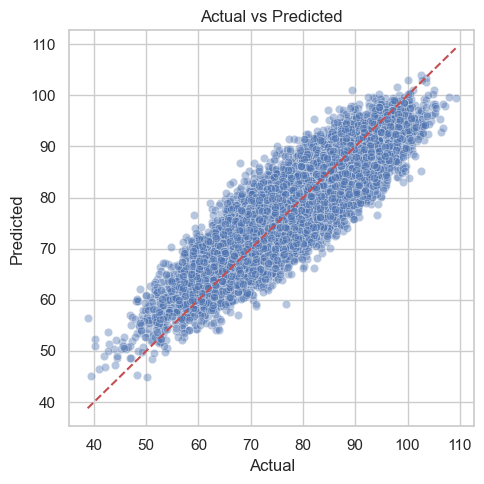

In [20]:
plt.figure(figsize=(5, 5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.show()

In [21]:
if existing is not None:
    r2_gain = r2 - existing_r2
    rmse_gain = existing_rmse - rmse

    if r2_gain > 0.01 and rmse_gain > 0:
        suggestion = "Use the new model: higher R2 and lower RMSE."
    else:
        suggestion = "Keep the existing model: no clear improvement yet."

    {"r2_gain": r2_gain, "rmse_gain": rmse_gain, "suggestion": suggestion}
else:
    "No existing metrics to compare. Use new model if it meets your requirements."

In [32]:
if existing is not None:
    summary = pd.DataFrame(
        [
            {
                "model": "existing",
                "r2": existing_r2,
                "mae": existing_mae,
                "rmse": existing_rmse,
            },
            {
                "model": "notebook_new",
                "r2": r2,
                "mae": mae,
                "rmse": rmse,
                "accuracy_within_5_years": accuracy,
            },
        ]
    )
    display(summary)
    print(f"R2 gain: {r2 - existing_r2:+.4f}")
    print(f"RMSE gain: {existing_rmse - rmse:+.4f}")
    print(f"Recommendation: {suggestion}")
else:
    print("Existing metrics unavailable, so no comparison was made.")

,model,r2,mae,rmse,accuracy_within_5_years
0,existing,0.571000,4.985000,6.264000,NaN
1,notebook_new,0.765003,3.693874,4.628283,0.72165


R2 gain: +0.1940
RMSE gain: +1.6357
Recommendation: Use the new model: higher R2 and lower RMSE.
